**Homework - Diana Legrand**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Part 1: Python basics

#### Present Value Function

In [2]:
def present_value(C_t, r, t):
    """
    Calculate the present value of a future cash flow.

    Parameters:
    C_t (float): Future cash flow at time t
    r (float): Discount rate (e.g., 0.03 for 3%)
    t (int): Time period

    Returns:
    float: Present value of the cash flow
    """
    return C_t / (1 + r) ** t

In [3]:
# Example of using:

C_10 = 100
r = 0.03
t = 10

pv = present_value(C_10, r, t)

print(f"Present Value of €{C_10} received in {t} years at {r*100:.2f}% rate: €{pv:.2f}")

Present Value of €100 received in 10 years at 3.00% rate: €74.41


In [4]:
C_3 = 4000
r = 0.3
t = 3

pv = present_value(C_3, r, t)

print(f"Present Value of €{C_3} received in {t} years at {r*100:.2f}% rate: €{pv:.2f}")

Present Value of €4000 received in 3 years at 30.00% rate: €1820.66


#### Present Value Plot

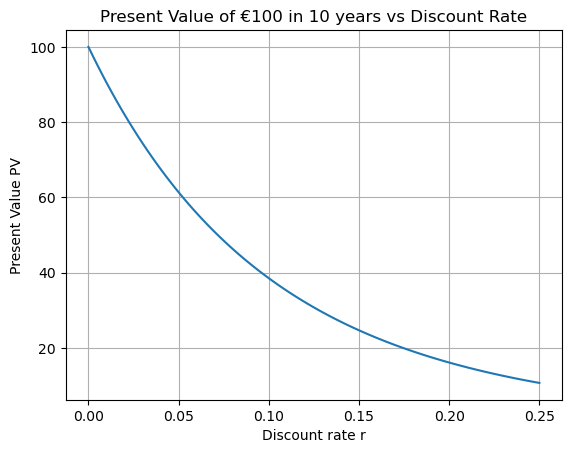

In [5]:
# Parameters
C_t = 100
t = 10

# r from 0% to 25%
r = np.linspace(0, 0.25, 100)

# Plot
plt.figure()
plt.plot(r, present_value(C_t, r, t))
plt.xlabel("Discount rate r")
plt.ylabel("Present Value PV")
plt.title("Present Value of €100 in 10 years vs Discount Rate")
plt.grid(True)

plt.show()

#### Discounted Cash Flow Computation

In [6]:
cash_flows = [10, 10, 110]
r = 0.05

discounted_flows = []

for t, cf in enumerate(cash_flows, start=1):
    pv = present_value(cf, r, t)
    discounted_flows.append(pv)
    print(f"Year {t}: Cash Flow = €{cf}, Present Value = €{pv:.2f}")

total_pv = sum(discounted_flows)
print(f"\nTotal Present Value: €{total_pv:.2f}")

Year 1: Cash Flow = €10, Present Value = €9.52
Year 2: Cash Flow = €10, Present Value = €9.07
Year 3: Cash Flow = €110, Present Value = €95.02

Total Present Value: €113.62


### Part 2: Working with data

In this assignment, you will work with financial data from a CSV file and use Python libraries such as NumPy, Pandas, Matplotlib and Seaborn to analyze and visualize the data. The data is stored in a file named 02_python_data.csv, which contains daily stock prices for various companies listed on Deutsche Börse (Xetra). The columns are labeled with Reuters identifier code (RIC). The first RIC '.GDAXI' is the german DAX index, the remaining RICs represent its constituents.

#### Data load

In [7]:
url = "https://raw.githubusercontent.com/cafawo/FinancialDataAnalytics/master/homework/02_python_data.csv"

prices = pd.read_csv(url, parse_dates=["Date"], index_col="Date")

In [8]:
prices.head()

,.GDAXI,SAPG.DE,SIEGn.DE,DTEGn.DE,AIRG.DE,ALVG.DE,MBGn.DE,VOWG_p.DE,BMWG.DE,SHLG.DE,...,CONG.DE,HEIG.DE,MTXGn.DE,CBKG.DE,RHMG.DE,BNRGn.DE,ZALG.DE,QIA.DE,PSHG_p.DE,1COV.DE
Date,,,,,,,,,,,,,,,,,,,,,
2022-04-29,14097.88,97.026932,117.78,17.570,105.50,216.20,67.10,148.94,78.51,51.26,...,66.02,55.26,193.65,6.282,214.8,73.94,37.83,44.04,79.54,41.29
2022-05-02,13939.07,95.982669,115.12,17.290,103.96,215.00,62.22,147.22,77.64,50.22,...,62.46,54.74,187.90,6.204,211.6,72.30,37.74,44.01,77.48,41.41
2022-05-03,14039.47,94.729554,114.56,17.376,106.44,217.00,62.88,150.20,79.98,50.42,...,64.32,55.22,197.10,6.412,222.4,72.18,38.07,44.06,79.58,39.40
2022-05-04,13970.82,92.979171,115.78,17.530,102.68,213.55,62.33,148.52,79.47,51.98,...,63.30,55.42,192.30,6.310,213.1,72.48,37.15,43.34,78.32,40.20
2022-05-05,13902.52,94.699718,116.58,17.592,108.96,199.76,61.00,147.18,78.03,53.06,...,60.54,54.18,189.95,6.188,211.0,71.34,33.21,44.05,77.78,38.75


In [9]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2022-04-29 to 2023-04-18
Data columns (total 40 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   .GDAXI     250 non-null    float64
 1   SAPG.DE    250 non-null    float64
 2   SIEGn.DE   250 non-null    float64
 3   DTEGn.DE   250 non-null    float64
 4   AIRG.DE    250 non-null    float64
 5   ALVG.DE    250 non-null    float64
 6   MBGn.DE    250 non-null    float64
 7   VOWG_p.DE  250 non-null    float64
 8   BMWG.DE    250 non-null    float64
 9   SHLG.DE    250 non-null    float64
 10  BAYGn.DE   250 non-null    float64
 11  DPWGn.DE   250 non-null    float64
 12  IFXGn.DE   250 non-null    float64
 13  MUVGn.DE   250 non-null    float64
 14  BASFn.DE   250 non-null    float64
 15  DB1Gn.DE   250 non-null    float64
 16  EONGn.DE   250 non-null    float64
 17  HNKG_p.DE  250 non-null    float64
 18  BEIG.DE    250 non-null    float64
 19  RWEG.DE    250 non-null    floa

In [10]:
prices = prices.apply(pd.to_numeric, errors='coerce')

#### Arithmetic as well as logarithmic returns for all assets

In [11]:
# Returns (no implicit filling)
returns = prices.pct_change(fill_method=None)
logreturns = np.log(prices / prices.shift(1))

print(returns.head())
print(logreturns.head())

              .GDAXI   SAPG.DE  SIEGn.DE  DTEGn.DE   AIRG.DE   ALVG.DE  \
Date                                                                     
2022-04-29       NaN       NaN       NaN       NaN       NaN       NaN   
2022-05-02 -0.011265 -0.010763 -0.022584 -0.015936 -0.014597 -0.005550   
2022-05-03  0.007203 -0.013056 -0.004864  0.004974  0.023855  0.009302   
2022-05-04 -0.004890 -0.018478  0.010649  0.008863 -0.035325 -0.015899   
2022-05-05 -0.004889  0.018505  0.006910  0.003537  0.061161 -0.064575   

             MBGn.DE  VOWG_p.DE   BMWG.DE   SHLG.DE  ...   CONG.DE   HEIG.DE  \
Date                                                 ...                       
2022-04-29       NaN        NaN       NaN       NaN  ...       NaN       NaN   
2022-05-02 -0.072727  -0.011548 -0.011081 -0.020289  ... -0.053923 -0.009410   
2022-05-03  0.010608   0.020242  0.030139  0.003982  ...  0.029779  0.008769   
2022-05-04 -0.008747  -0.011185 -0.006377  0.030940  ... -0.015858  0.003622   
2

In [12]:
returns.head()

,.GDAXI,SAPG.DE,SIEGn.DE,DTEGn.DE,AIRG.DE,ALVG.DE,MBGn.DE,VOWG_p.DE,BMWG.DE,SHLG.DE,...,CONG.DE,HEIG.DE,MTXGn.DE,CBKG.DE,RHMG.DE,BNRGn.DE,ZALG.DE,QIA.DE,PSHG_p.DE,1COV.DE
Date,,,,,,,,,,,,,,,,,,,,,
2022-04-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-02,-0.011265,-0.010763,-0.022584,-0.015936,-0.014597,-0.005550,-0.072727,-0.011548,-0.011081,-0.020289,...,-0.053923,-0.009410,-0.029693,-0.012416,-0.014898,-0.022180,-0.002379,-0.000681,-0.025899,0.002906
2022-05-03,0.007203,-0.013056,-0.004864,0.004974,0.023855,0.009302,0.010608,0.020242,0.030139,0.003982,...,0.029779,0.008769,0.048962,0.033527,0.051040,-0.001660,0.008744,0.001136,0.027104,-0.048539
2022-05-04,-0.004890,-0.018478,0.010649,0.008863,-0.035325,-0.015899,-0.008747,-0.011185,-0.006377,0.030940,...,-0.015858,0.003622,-0.024353,-0.015908,-0.041817,0.004156,-0.024166,-0.016341,-0.015833,0.020305
2022-05-05,-0.004889,0.018505,0.006910,0.003537,0.061161,-0.064575,-0.021338,-0.009022,-0.018120,0.020777,...,-0.043602,-0.022375,-0.012220,-0.019334,-0.009855,-0.015728,-0.106057,0.016382,-0.006895,-0.036070


In [13]:
logreturns.head()

,.GDAXI,SAPG.DE,SIEGn.DE,DTEGn.DE,AIRG.DE,ALVG.DE,MBGn.DE,VOWG_p.DE,BMWG.DE,SHLG.DE,...,CONG.DE,HEIG.DE,MTXGn.DE,CBKG.DE,RHMG.DE,BNRGn.DE,ZALG.DE,QIA.DE,PSHG_p.DE,1COV.DE
Date,,,,,,,,,,,,,,,,,,,,,
2022-04-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-02,-0.011329,-0.010821,-0.022843,-0.016065,-0.014705,-0.005566,-0.075508,-0.011615,-0.011143,-0.020497,...,-0.055431,-0.009455,-0.030142,-0.012494,-0.015010,-0.022430,-0.002382,-0.000681,-0.026240,0.002902
2022-05-03,0.007177,-0.013142,-0.004876,0.004962,0.023575,0.009259,0.010552,0.020040,0.029694,0.003975,...,0.029344,0.008731,0.047801,0.032977,0.049780,-0.001661,0.008706,0.001135,0.026743,-0.049757
2022-05-04,-0.004902,-0.018651,0.010593,0.008824,-0.035964,-0.016026,-0.008785,-0.011248,-0.006397,0.030471,...,-0.015985,0.003615,-0.024655,-0.016036,-0.042716,0.004148,-0.024463,-0.016476,-0.015960,0.020101
2022-05-05,-0.004901,0.018336,0.006886,0.003531,0.059363,-0.066754,-0.021569,-0.009063,-0.018286,0.020564,...,-0.044581,-0.022629,-0.012296,-0.019524,-0.009903,-0.015853,-0.112113,0.016249,-0.006919,-0.036736


#### Histogram of DAX returns

In [14]:
dax_returns = returns[".GDAXI"].dropna()

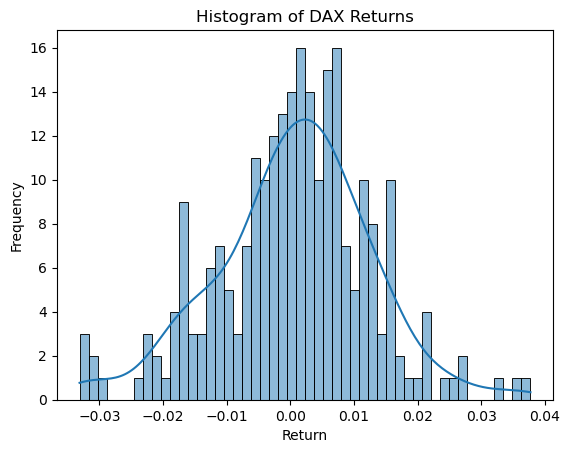

In [15]:
plt.figure()
sns.histplot(dax_returns, bins=50, kde=True)

plt.xlabel("Return")
plt.ylabel("Frequency")
plt.title("Histogram of DAX Returns")

# Save with required prefix
plt.savefig("02_python_dax_hist.png", dpi=300, bbox_inches="tight")

plt.show()

#### DAX Price and Returns

In [40]:
dax_price = prices[".GDAXI"]
dax_returns = returns[".GDAXI"]

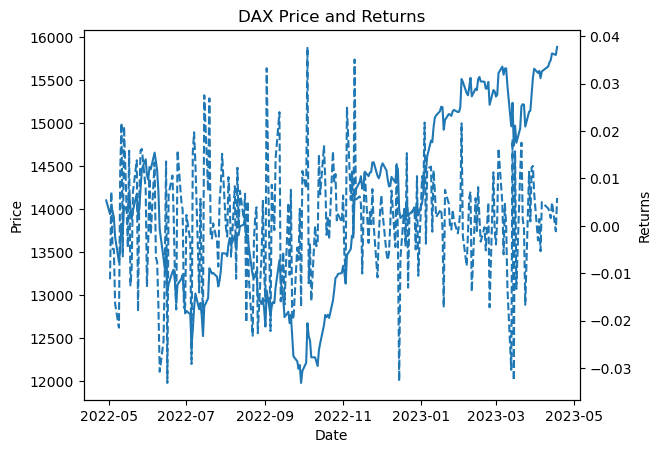

In [41]:
fig, ax1 = plt.subplots()

# Plot price (left axis)
ax1.plot(dax_price, label="DAX Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")

# Create second axis
ax2 = ax1.twinx()
# Plot returns (right axis)
ax2.plot(dax_returns, linestyle='--', label="DAX Returns")
ax2.set_ylabel("Returns")

plt.title("DAX Price and Returns")
plt.savefig("02_python_price_returns.png", dpi=300, bbox_inches="tight")
plt.show()

#### The company with the highest average return

In [17]:
# Compute average returns for each asset
mean_returns = returns.mean()

In [18]:
mean_returns.head()

.GDAXI      0.000552
SAPG.DE     0.000860
SIEGn.DE    0.001091
DTEGn.DE    0.001042
AIRG.DE     0.000962
dtype: float64

In [19]:
mean_returns.idxmax()

'CBKG.DE'

In [20]:
# Find the company with the highest average return
best_company = mean_returns.idxmax()
best_value = mean_returns.max()

print(f"The company with the highest average return: {best_company}")
print(f"Highest average return: {best_value:.6f}")

The company with the highest average return: CBKG.DE
Highest average return: 0.002437


#### Heat map of the correlations between the arithmetic returns of the first 10 assets

In [21]:
# Select first 10 assets (columns), all dates
subset = returns.iloc[:, :10]

In [22]:
# Compute correlation matrix
corr_matrix = subset.corr()

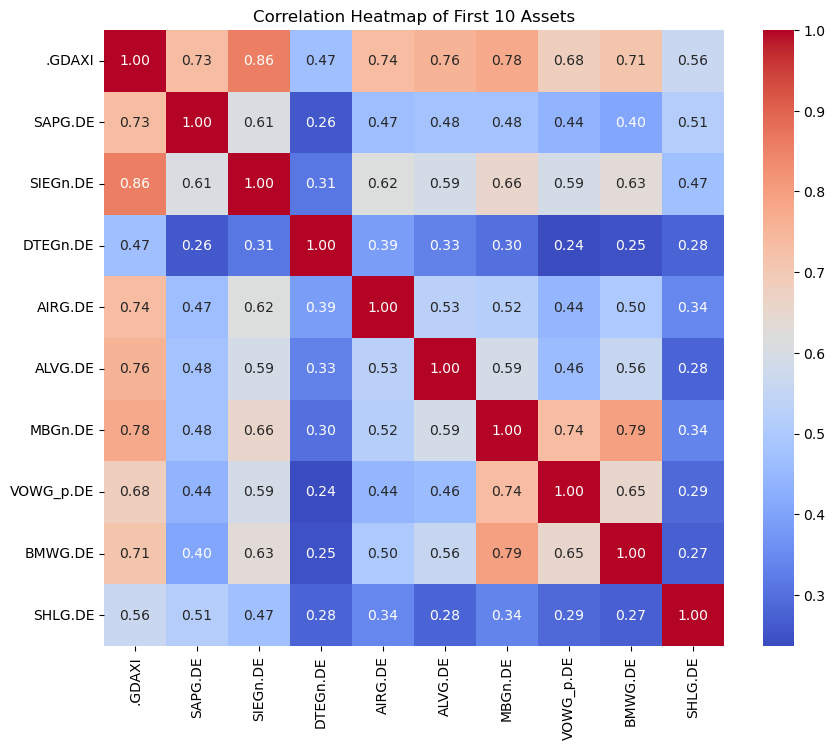

In [23]:
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of First 10 Assets")

# Save figure
plt.savefig("02_python_correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Task:
Considering all assets in the data, pick two pairs of stocks:

the pair with the highest correlation and
the pair with the lowest correlation.
Create scatter plots for both pairs.

#### Highest Correlation and Lowest Correlation of stocks pairs

In [24]:
corr_matrix = returns.corr()

In [25]:
corr_matrix

,.GDAXI,SAPG.DE,SIEGn.DE,DTEGn.DE,AIRG.DE,ALVG.DE,MBGn.DE,VOWG_p.DE,BMWG.DE,SHLG.DE,...,CONG.DE,HEIG.DE,MTXGn.DE,CBKG.DE,RHMG.DE,BNRGn.DE,ZALG.DE,QIA.DE,PSHG_p.DE,1COV.DE
.GDAXI,1.000000,0.732677,0.856431,0.469028,0.736455,0.757704,0.778990,0.681716,0.711092,0.563774,...,0.748261,0.779423,0.688535,0.554449,0.360950,0.701601,0.647285,0.354730,0.642199,0.668296
SAPG.DE,0.732677,1.000000,0.608460,0.259135,0.465423,0.477788,0.476619,0.438707,0.404103,0.514152,...,0.451885,0.481581,0.424283,0.298183,0.227188,0.471044,0.523525,0.386176,0.423253,0.352907
SIEGn.DE,0.856431,0.608460,1.000000,0.314113,0.616709,0.590616,0.656643,0.588755,0.631080,0.470988,...,0.625979,0.705902,0.574626,0.480453,0.234195,0.611649,0.554878,0.298680,0.543606,0.648440
DTEGn.DE,0.469028,0.259135,0.314113,1.000000,0.387458,0.334680,0.300302,0.236876,0.247228,0.279349,...,0.278732,0.309016,0.374506,0.214752,0.137222,0.302950,0.140910,0.118044,0.249626,0.194369
AIRG.DE,0.736455,0.465423,0.616709,0.387458,1.000000,0.528805,0.519897,0.443569,0.498957,0.342086,...,0.463965,0.558084,0.741644,0.459637,0.339064,0.512182,0.414973,0.190565,0.440283,0.453232
ALVG.DE,0.757704,0.477788,0.590616,0.334680,0.528805,1.000000,0.590033,0.458649,0.558748,0.281235,...,0.573801,0.620671,0.533868,0.533582,0.354203,0.531681,0.433020,0.169516,0.464092,0.470785
MBGn.DE,0.778990,0.476619,0.656643,0.300302,0.519897,0.590033,1.000000,0.736309,0.794949,0.338171,...,0.748647,0.727152,0.536436,0.521078,0.340602,0.530694,0.522134,0.177925,0.705663,0.598964
VOWG_p.DE,0.681716,0.438707,0.588755,0.236876,0.443569,0.458649,0.736309,1.000000,0.652957,0.288110,...,0.682154,0.586518,0.459728,0.476227,0.330201,0.454146,0.461101,0.162694,0.783486,0.537593
BMWG.DE,0.711092,0.404103,0.631080,0.247228,0.498957,0.558748,0.794949,0.652957,1.000000,0.269824,...,0.655198,0.656810,0.521170,0.449344,0.326437,0.487881,0.409570,0.136874,0.637632,0.598023
SHLG.DE,0.563774,0.514152,0.470988,0.279349,0.342086,0.281235,0.338171,0.288110,0.269824,1.000000,...,0.357437,0.354352,0.329047,0.096571,0.138107,0.457677,0.389078,0.440283,0.238223,0.319281


In [26]:
# Copy matrix
corr = corr_matrix.copy()

In [27]:
# Remove diagonal
np.fill_diagonal(corr.values, np.nan)

In [28]:
# Highest correlation pair
max_pair = corr.unstack().idxmax()
max_value = corr.unstack().max()

In [29]:
# Lowest correlation pair
min_pair = corr.unstack().idxmin()
min_value = corr.unstack().min()

In [30]:
print("Highest correlation pair:", max_pair, max_value)
print("Lowest correlation pair:", min_pair, min_value)

Highest correlation pair: ('.GDAXI', 'SIEGn.DE') 0.8564307328469356
Lowest correlation pair: ('CBKG.DE', 'QIA.DE') 0.013871935085845654


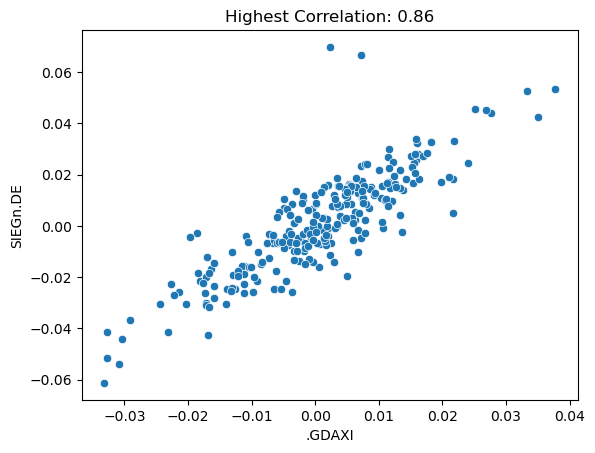

In [31]:
# Highest correlation scatter
plt.figure()
sns.scatterplot(
    x=returns[max_pair[0]],
    y=returns[max_pair[1]]
)
plt.xlabel(max_pair[0])
plt.ylabel(max_pair[1])
plt.title(f"Highest Correlation: {max_value:.2f}")

plt.savefig("02_python_scatter_high_corr.png", dpi=300, bbox_inches="tight")
plt.show()

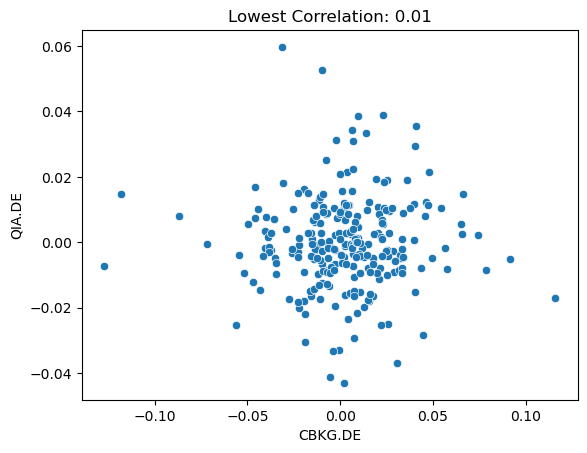

In [32]:
# Lowest correlation scatter
plt.figure()
sns.scatterplot(
    x=returns[min_pair[0]],
    y=returns[min_pair[1]]
)
plt.xlabel(min_pair[0])
plt.ylabel(min_pair[1])
plt.title(f"Lowest Correlation: {min_value:.2f}")

plt.savefig("02_python_scatter_low_corr.png", dpi=300, bbox_inches="tight")
plt.show()

#### Annualized volatility and return of each asset in the dataset

Task:

Calculate the annualized volatility) and return of each asset in the dataset. Assume there are 252 trading days in a year. (Use log-returns!)

Also calculate the Sharpe ratio for each asset, assuming a risk free rate of p.a..

In [33]:
# Annualized return
annual_return = logreturns.mean() * 252

In [34]:
# Annualized volatility
annual_volatility = logreturns.std() * np.sqrt(252)

In [35]:
# Combine into one table
summary = pd.DataFrame({
    "Annualized Return": annual_return,
    "Annualized Volatility": annual_volatility
})

In [36]:
summary

,Annualized Return,Annualized Volatility
.GDAXI,0.120640,0.192007
SAPG.DE,0.187016,0.243553
SIEGn.DE,0.225660,0.313924
DTEGn.DE,0.248276,0.169142
AIRG.DE,0.197860,0.299162
ALVG.DE,0.013023,0.225913
MBGn.DE,0.045276,0.332984
VOWG_p.DE,-0.164629,0.346088
BMWG.DE,0.285525,0.267520
SHLG.DE,0.046686,0.310205


#### Plot of monthly prices for 'BMWG.DE'

Task:
As you can see, we are using daily data so far. Re-sample the data to monthly frequency and plot monthly prices for 'BMWG.DE'.

In [37]:
monthly_prices = prices.resample("ME").last()

In [38]:
bmw_monthly = monthly_prices["BMWG.DE"]

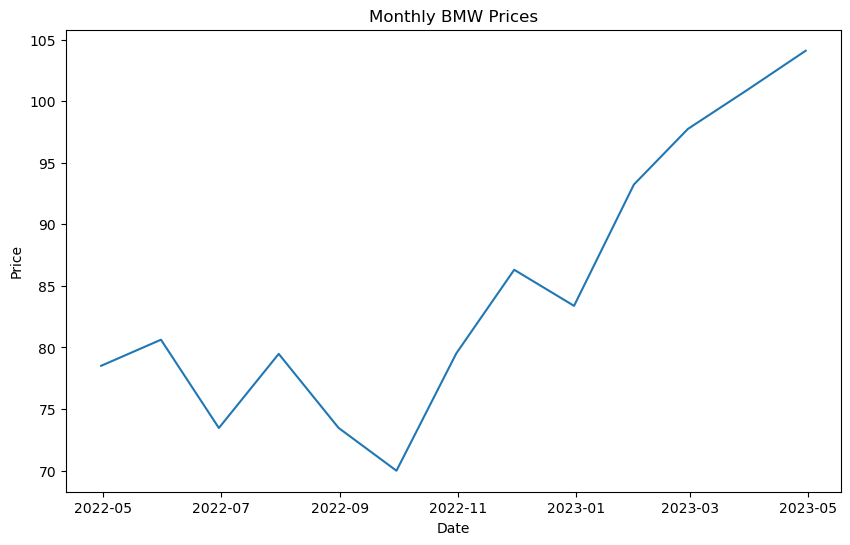

In [39]:
# Plot
plt.figure(figsize=(10, 6))

sns.lineplot(x=bmw_monthly.index, y=bmw_monthly)

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Monthly BMW Prices")

# Save figure
plt.savefig("02_python_bmw_monthly_prices.png",
            dpi=300,
            bbox_inches="tight")

plt.show()